<a href="https://colab.research.google.com/github/starsyntaxx/Olist-delivery-prediction/blob/main/notebooks/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving final_ml_dataset.csv to final_ml_dataset.csv


In [38]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("final_ml_dataset.csv")

In [ ]:
df.shape

(96455, 41)

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price_sum,price_mean,...,seller_state_nunique,seller_city_nunique,delivery_time_days,approval_delay_days,carrier_delay_days,transit_time_days,delivery_late_days,product_volume_cm3,product_density,size_complexity
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,29.99,...,1,1,8,0.007431,2.366493,6.062650,-7.107488,1976.0,0.253036,40.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,118.70,...,1,1,13,1.279745,0.462882,12.039410,-5.355729,4693.0,0.085233,51.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,159.90,...,1,1,9,0.011505,0.204595,9.178113,-17.245498,9576.0,0.043860,64.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,45.00,...,1,1,13,0.012419,3.745833,9.450498,-12.980069,6000.0,0.075000,60.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,19.90,...,1,1,2,0.042940,0.893113,1.937824,-9.238171,11475.0,0.021786,81.0


In [ ]:
model_df.head()

,order_status,order_estimated_delivery_date,price_sum,price_max,freight_value_sum,freight_value_max,order_item_id_count,product_id_nunique,seller_id_nunique,product_weight_g_sum,...,customer_state_freq_mean,seller_state_tier_mean,customer_state_tier_mean,seller_geo_missing_max,customer_geo_missing_max,seller_state_nunique,seller_city_nunique,product_volume_cm3,product_density,size_complexity
0,delivered,2017-10-18,29.99,29.99,8.72,8.72,1,1,1,500.0,...,0.421207,3.0,3.0,0,0,1,1,1976.0,0.253036,40.0
1,delivered,2018-08-13,118.70,118.70,22.76,22.76,1,1,1,400.0,...,0.033724,3.0,1.0,0,0,1,1,4693.0,0.085233,51.0
2,delivered,2018-09-04,159.90,159.90,19.22,19.22,1,1,1,420.0,...,0.020710,3.0,1.0,0,0,1,1,9576.0,0.043860,64.0
3,delivered,2017-12-15,45.00,45.00,27.20,27.20,1,1,1,450.0,...,0.004696,2.0,1.0,0,0,1,1,6000.0,0.075000,60.0
4,delivered,2018-02-26,19.90,19.90,8.72,8.72,1,1,1,250.0,...,0.421207,3.0,3.0,0,0,1,1,11475.0,0.021786,81.0


In [4]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [5]:
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.total_seconds() / 86400

In [6]:
df['approval_delay_days'] = (
    df['order_approved_at'] -
    df['order_purchase_timestamp']
).dt.total_seconds() / 86400

In [7]:
df['carrier_delay_days'] = (
    df['order_delivered_carrier_date'] -
    df['order_approved_at']
).dt.total_seconds() / 86400

In [8]:
df['transit_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_delivered_carrier_date']
).dt.total_seconds() / 86400

In [9]:
df['delivery_late_days'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.total_seconds() / 86400

Product measurement values

In [10]:
df['product_volume_cm3'] = (
    df['product_length_cm_mean'] *
    df['product_height_cm_mean'] *
    df['product_width_cm_mean']
)

In [11]:
df['product_density'] = (
    df['product_weight_g_sum'] /
    df['product_volume_cm3']
)

In [12]:
import numpy as np

df['log_weight'] = np.log1p(df['product_weight_g_sum'])

In [13]:
df['size_complexity'] = (
    df['product_length_cm_mean'] +
    df['product_height_cm_mean'] +
    df['product_width_cm_mean']
)

In [14]:
df["delivery_time_days"] = (

    df["order_delivered_customer_date"]
    -
    df["order_purchase_timestamp"]

).dt.days

In [15]:
df['log_volume'] = np.log1p(df['product_volume_cm3'])

In [16]:
cols_to_drop = [

    # identifiers
    "order_id",
    "customer_id",

    # leakage timestamps
    "order_delivered_carrier_date",
    "order_delivered_customer_date",

    # target leakage
    "carrier_delay_days",
    "transit_time_days",
    "delivery_late_days",

    # approval leakage
    "order_approved_at",
    "order_status",
    "approval_delay_days",

    # redundant means
    "price_mean",
    "freight_value_mean",

    # optional geographic redundancy
    "lat_diff_mean",
    "lng_diff_mean"
]

model_df = df.drop(columns=cols_to_drop)

In [17]:
# =========================================
# PURCHASE TIME FEATURES
# =========================================

model_df["purchase_hour"] = (
    model_df["order_purchase_timestamp"]
    .dt.hour
)

model_df["purchase_day"] = (
    model_df["order_purchase_timestamp"]
    .dt.day
)

model_df["purchase_dayofweek"] = (
    model_df["order_purchase_timestamp"]
    .dt.dayofweek
)

model_df["purchase_month"] = (
    model_df["order_purchase_timestamp"]
    .dt.month
)

model_df["purchase_week"] = (
    model_df["order_purchase_timestamp"]
    .dt.isocalendar().week.astype(int)
)

model_df["purchase_quarter"] = (
    model_df["order_purchase_timestamp"]
    .dt.quarter
)

model_df["is_weekend"] = (
    model_df["purchase_dayofweek"] >= 5
).astype(int)

In [18]:
model_df.drop(
    columns=["order_purchase_timestamp"],
    inplace=True
)

In [19]:
model_df.drop(
    columns=[
        "order_estimated_delivery_date"
    ],
    inplace=True
)

In [20]:
num_cols = model_df.select_dtypes(include=["float64", "int64"]).columns

model_df[num_cols] = model_df[num_cols].fillna(
    model_df[num_cols].median()
)

In [21]:
def cap_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

    return df

In [22]:
outlier_cols = [
    "delivery_time_days",
    "price_sum",
    "freight_value_sum",
    "delivery_distance_km_mean",
    "product_weight_g_sum"
]

for col in outlier_cols:
    model_df = cap_outliers(model_df, col)

In [ ]:
model_df.isnull().sum()

,0
price_sum,0
price_max,0
freight_value_sum,0
freight_value_max,0
order_item_id_count,0
product_id_nunique,0
seller_id_nunique,0
product_weight_g_sum,0
product_weight_g_mean,0
product_length_cm_mean,0


In [26]:
# ==============================
# 1. Define Features and Target
# ==============================

X = model_df.drop(columns=['delivery_time_days'])
y = model_df['delivery_time_days']


# ==============================
# 2. Train-Test Split
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:


# ==============================
# 3. Train Model
# ==============================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Evaluate Model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 4.08776105437769
MSE: 28.87818253026598
R2 Score: 0.43198952595547235


In [ ]:
errors = y_test - y_pred

In [ ]:
error_df = X_test.copy()
error_df["actual"] = y_test
error_df["predicted"] = y_pred
error_df["error"] = errors
error_df["abs_error"] = errors.abs()

In [ ]:
error_df["error"].describe()

,error
count,19291.000000
mean,-0.231733
std,5.368983
min,-20.800000
25%,-3.605000
50%,-1.145000
75%,2.317500
max,25.630000


In [37]:
base_mae = mean_absolute_error(y_test, y_pred_base)
base_mse = mean_squared_error(y_test, y_pred_base)
base_r2 = r2_score(y_test, y_pred_base)

XG Boost

In [23]:
from xgboost import XGBRegressor

In [28]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [29]:
y_pred_xgb = xgb_model.predict(X_test)

In [36]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("R2:", xgb_r2)

XGBoost Results
MAE: 3.9924289502003014
MSE: 27.853709973523173
R2: 0.4521400718560399


In [39]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

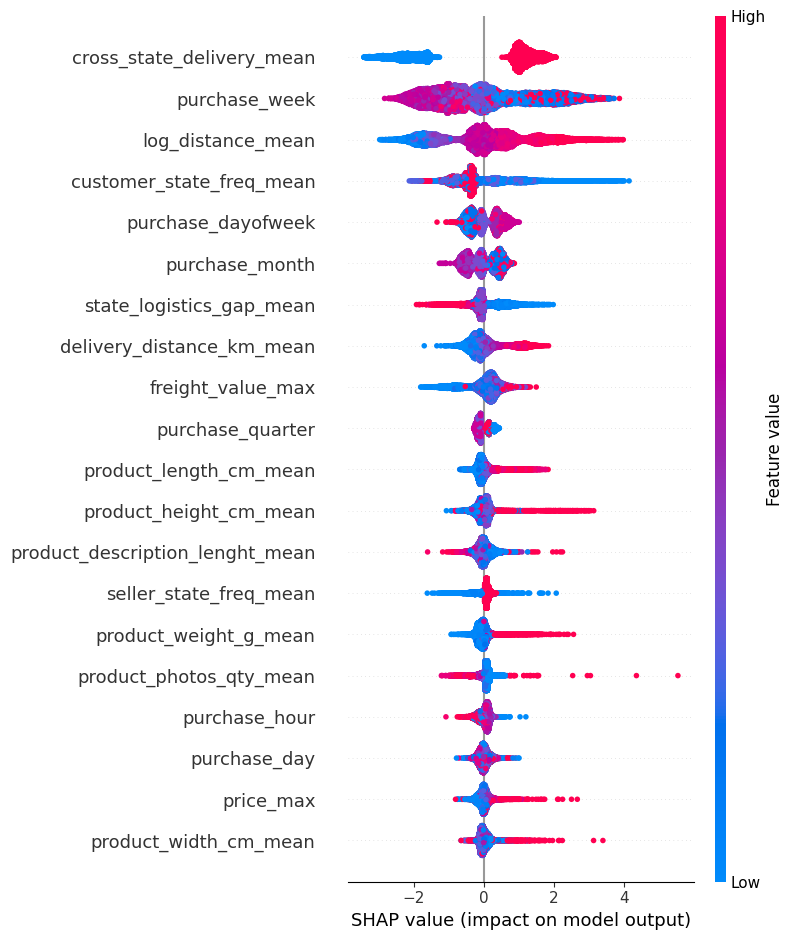

In [40]:
shap.summary_plot(shap_values, X_test)